In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [160]:
df = pd.read_csv("cleaned_resumeJD_pairs.csv")

In [161]:
df.head(5)

,resume_text,job_description,match_label,match_score,match_label_lower,resume_len,jd_len
0,BI Analyst with 7 years of experience based in...,Fathom is hiring a Financial Analyst (Berlin)....,medium,0.53,medium,75,71
1,Data Scientist with 13 years of experience bas...,Lumen is hiring a Senior UX Designer (Singapor...,low,0.26,low,79,74
2,Software Engineer with 8 years of experience b...,Acme Corp is hiring a Product Manager (Seattle...,low,0.31,low,71,80
3,Backend Engineer with 15 years of experience b...,Umbrella Labs is hiring a Senior Data Scientis...,medium,0.46,medium,70,83
4,Cloud Engineer with 5 years of experience base...,Cobalt is hiring a Platform Engineer (Austin)....,high,0.77,high,69,70


In [162]:
df.columns

Index(['resume_text', 'job_description', 'match_label', 'match_score',
       'match_label_lower', 'resume_len', 'jd_len'],
      dtype='object')

In [163]:
print("Loading BERT model")
model = SentenceTransformer("all-mpnet-base-v2")

Loading BERT model


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [164]:
print(f"Model: all-mpnet-base-v2")
print(f"Max tokens: {model.max_seq_length}")


Model: all-mpnet-base-v2
Max tokens: 384


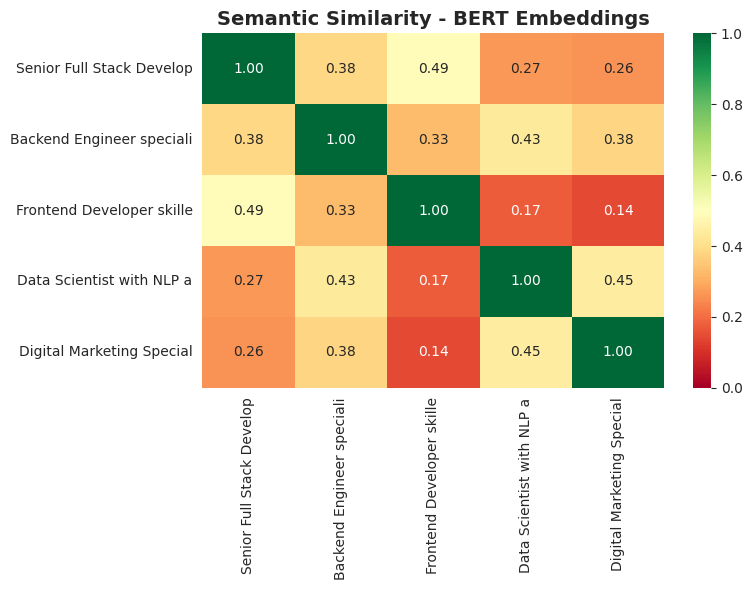

In [165]:
# Part 2: Understanding Embeddings

texts = [
    "Senior Full Stack Developer (React, Node.js, AWS)",
    "Backend Engineer specializing in Python and Django",
    "Frontend Developer skilled in React and Tailwind CSS",
    "Data Scientist with NLP and PyTorch experience",
    "Digital Marketing Specialist and SEO Manager",
]

embeddings = model.encode(texts)
sim_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(8, 6))
sns.heatmap(
    sim_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    xticklabels=[t[:25] for t in texts],
    yticklabels=[t[:25] for t in texts],
    vmin=0,
    vmax=1,
)
plt.title("Semantic Similarity - BERT Embeddings", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

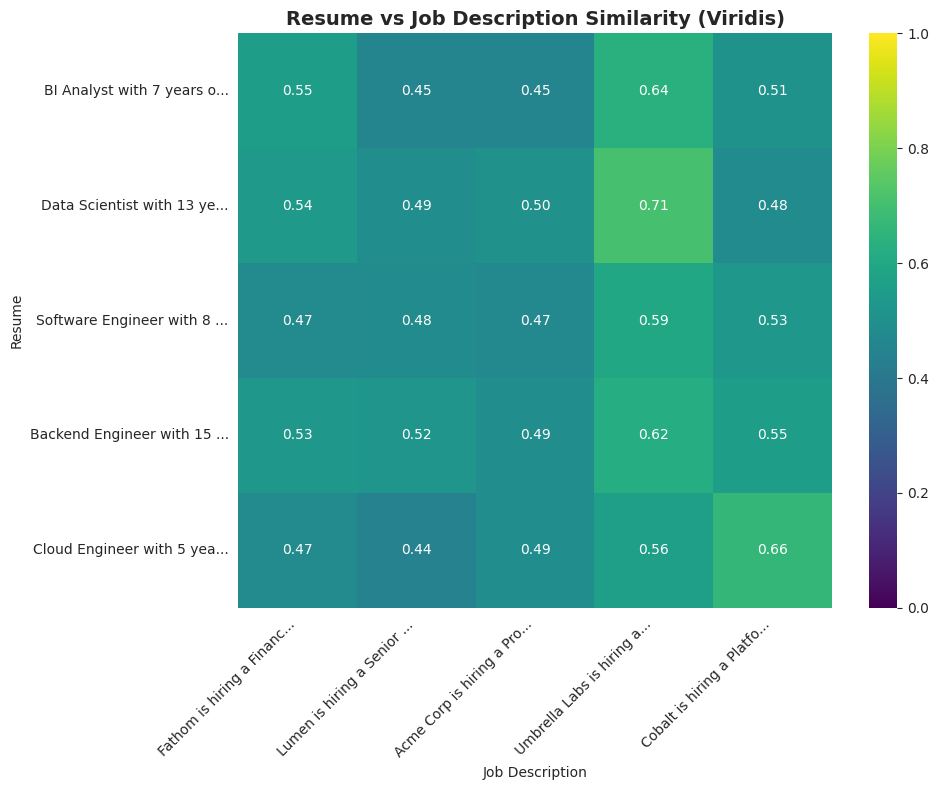

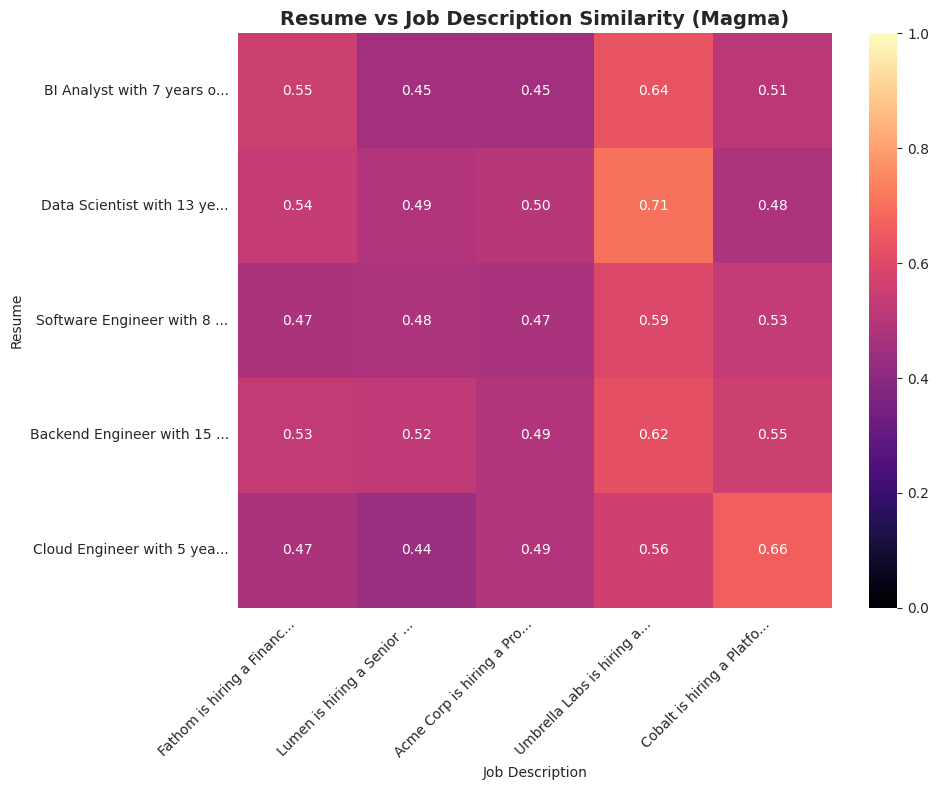

In [166]:
from sklearn.metrics.pairwise import cosine_similarity

# Generate embeddings for resume and job description texts
resume_embeddings = model.encode(df['resume_text'].tolist(), show_progress_bar=True)
jd_embeddings = model.encode(df['job_description'].tolist(), show_progress_bar=True)

# Calculate cosine similarity matrix
similarity_matrix = cosine_similarity(resume_embeddings, jd_embeddings)

# Prepare truncated labels for heatmap axes
resume_labels = [text[:25] + "..." for text in df['resume_text'][:5]]
jd_labels = [text[:25] + "..." for text in df['job_description'][:5]]

# Plot 1: Using 'Viridis' color scheme
plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix[:5, :5],
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=jd_labels,
    yticklabels=resume_labels,
    vmin=0,
    vmax=1
)
plt.title("Resume vs Job Description Similarity (Viridis)", fontsize=14, fontweight="bold")
plt.xlabel("Job Description")
plt.ylabel("Resume")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot 2: Using 'Magma' color scheme
plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix[:5, :5],
    annot=True,
    fmt=".2f",
    cmap="magma",
    xticklabels=jd_labels,
    yticklabels=resume_labels,
    vmin=0,
    vmax=1
)
plt.title("Resume vs Job Description Similarity (Magma)", fontsize=14, fontweight="bold")
plt.xlabel("Job Description")
plt.ylabel("Resume")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [167]:
# Calculate the cosine similarity for each resume-job description pair in the DataFrame
df['bert_similarity'] = [similarity_matrix[i, i] for i in range(len(df))]

print("Cosine similarity computed for all pairs.")
print(df[['match_label', 'match_score', 'bert_similarity']].head(10))

Cosine similarity computed for all pairs.
  match_label  match_score  bert_similarity
0      medium         0.53         0.554188
1         low         0.26         0.489453
2         low         0.31         0.471076
3      medium         0.46         0.620440
4        high         0.77         0.660347
5        high         0.92         0.608102
6         low         0.13         0.515025
7      medium         0.45         0.619569
8      medium         0.46         0.562903
9      medium         0.48         0.479238


In [168]:
# Base Model Performance: How Good Is BERT Out of the Box?

mae = np.mean(np.abs(df['match_score'] - df['bert_similarity']))
rmse = np.sqrt(np.mean((df['match_score'] - df['bert_similarity'])**2))

print("Base BERT Model Performance (before fine-tuning)")
print(f"  MAE  : {mae:.4f}   (lower is better)")
print(f"  RMSE : {rmse:.4f}   (lower is better)")

Base BERT Model Performance (before fine-tuning)
  MAE  : 0.1789   (lower is better)
  RMSE : 0.2188   (lower is better)


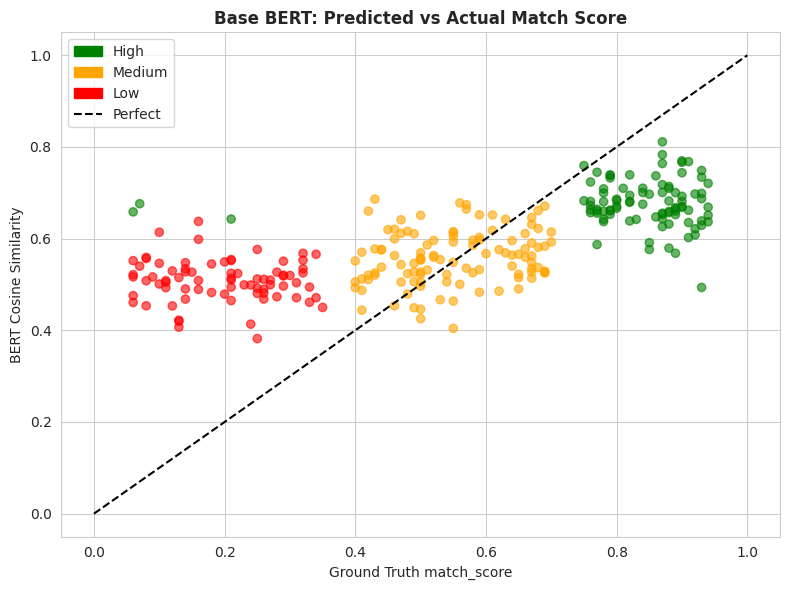

In [169]:
# Scatter: predicted vs ground truth
plt.figure(figsize=(8, 6))
colors = df['match_label'].map({'low': 'red', 'medium': 'orange', 'high': 'green'})
plt.scatter(df['match_score'], df['bert_similarity'], c=colors, alpha=0.6)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect prediction')
plt.xlabel('Ground Truth match_score')
plt.ylabel('BERT Cosine Similarity')
plt.title('Base BERT: Predicted vs Actual Match Score', fontweight='bold')

# Legend
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='green', label='High'),
    Patch(color='orange', label='Medium'),
    Patch(color='red', label='Low'),
    plt.Line2D([0], [0], color='black', linestyle='--', label='Perfect')
])
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Match Label')

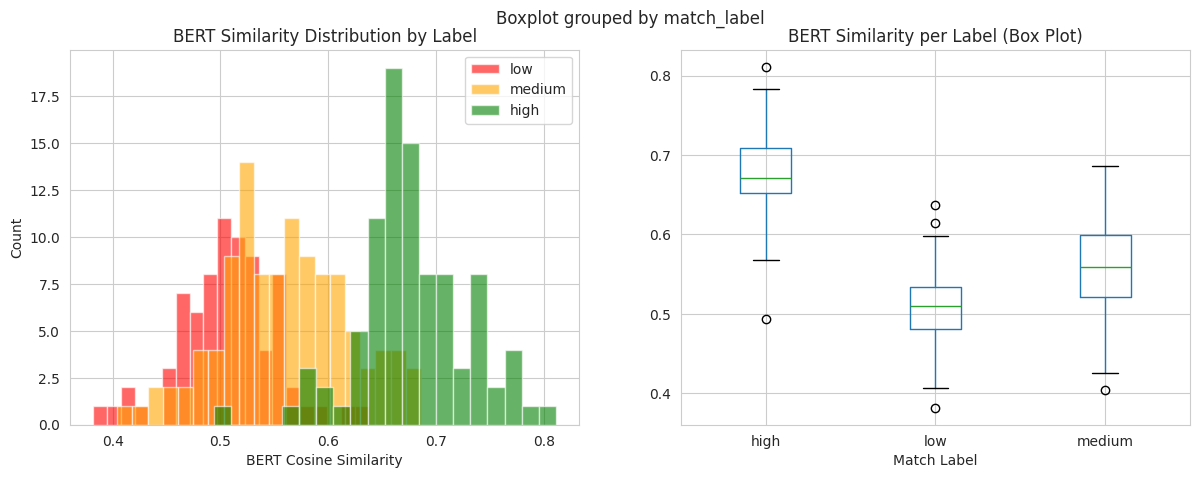

In [170]:
# Similarity Distribution by Label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: BERT similarity grouped by label
for label, color in [('low', 'red'), ('medium', 'orange'), ('high', 'green')]:
    subset = df[df['match_label'] == label]['bert_similarity']
    axes[0].hist(subset, bins=20, alpha=0.6, label=label, color=color)
axes[0].set_xlabel('BERT Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('BERT Similarity Distribution by Label')
axes[0].legend()

# Box plot
df.boxplot(column='bert_similarity', by='match_label',
           positions=[0, 1, 2], ax=axes[1])
axes[1].set_title('BERT Similarity per Label (Box Plot)')
axes[1].set_xlabel('Match Label')

In [171]:
import pickle

with open('resume_embeddings.pkl', 'wb') as f:
    pickle.dump({
        'resume_embeddings': resume_embeddings,
        'jd_embeddings': jd_embeddings,
        'match_scores': df['match_score'].tolist(),
        'match_labels': df['match_label'].tolist(),
    }, f)

print("Saved: resume_embeddings.pkl")
print(f"  resume_embeddings: {resume_embeddings.shape}")
print(f"  jd_embeddings:     {jd_embeddings.shape}")
print()
print("These will be loaded for fine-tuning.")

Saved: resume_embeddings.pkl
  resume_embeddings: (280, 768)
  jd_embeddings:     (280, 768)

These will be loaded for fine-tuning.
